# Data Loading

In [1]:
import pandas as pd

data = pd.read_csv("predictions.csv", index_col = 0)
data.rename(columns={"pIC50": "real pIC50", "y_pred": "predicted pIC50"}, inplace=True)
data = data[["target_organism", "real pIC50", "predicted pIC50"]]
data.head()

,target_organism,real pIC50,predicted pIC50
3218,Salmonella enterica subsp. enterica serovar Ty...,1.501689,1.560952
9448,Staphylococcus aureus,1.966172,2.144288
2491,Raoultella planticola,2.958607,3.258607
319,Salmonella enterica subsp. enterica serovar Ty...,1.478862,1.632399
508,Staphylococcus aureus,1.271646,1.866465


# Prediction Analysis

## Metrics

In [2]:
y_real = data["real pIC50"]
y_pred = data["predicted pIC50"]

from sklearn.metrics import r2_score, mean_squared_error
print("R² score: ", r2_score(y_real, y_pred))
print("MSE: ", mean_squared_error(y_real, y_pred))
print("RMSE:", mean_squared_error(y_real, y_pred)**0.5)

R² score:  0.5318878274862268
MSE:  0.23075778278821077
RMSE: 0.4803725458310568


# Graph

Text(0, 0.5, 'predicted pIC50')

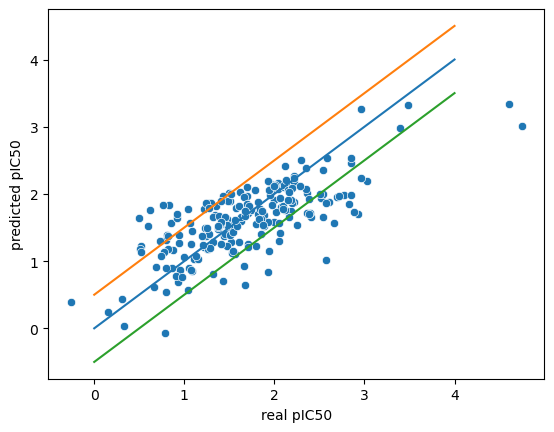

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x = y_real, y= y_pred)
sns.lineplot(x = [0,4], y=[0,4])
sns.lineplot(x = [0,4], y=[0.5, 4.5])
sns.lineplot(x = [0,4], y=[-0.5, 3.5])
plt.xlabel('real pIC50')
plt.ylabel('predicted pIC50')

<Axes: ylabel='Count'>

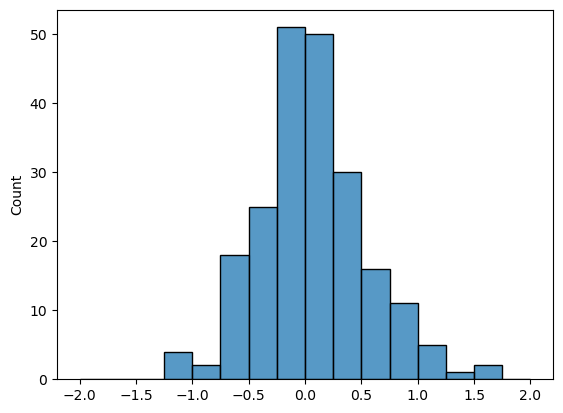

In [4]:
sns.histplot((y_real-y_pred), bins=16, binrange=(-2, 2))

## RESULTS BY SPECIES

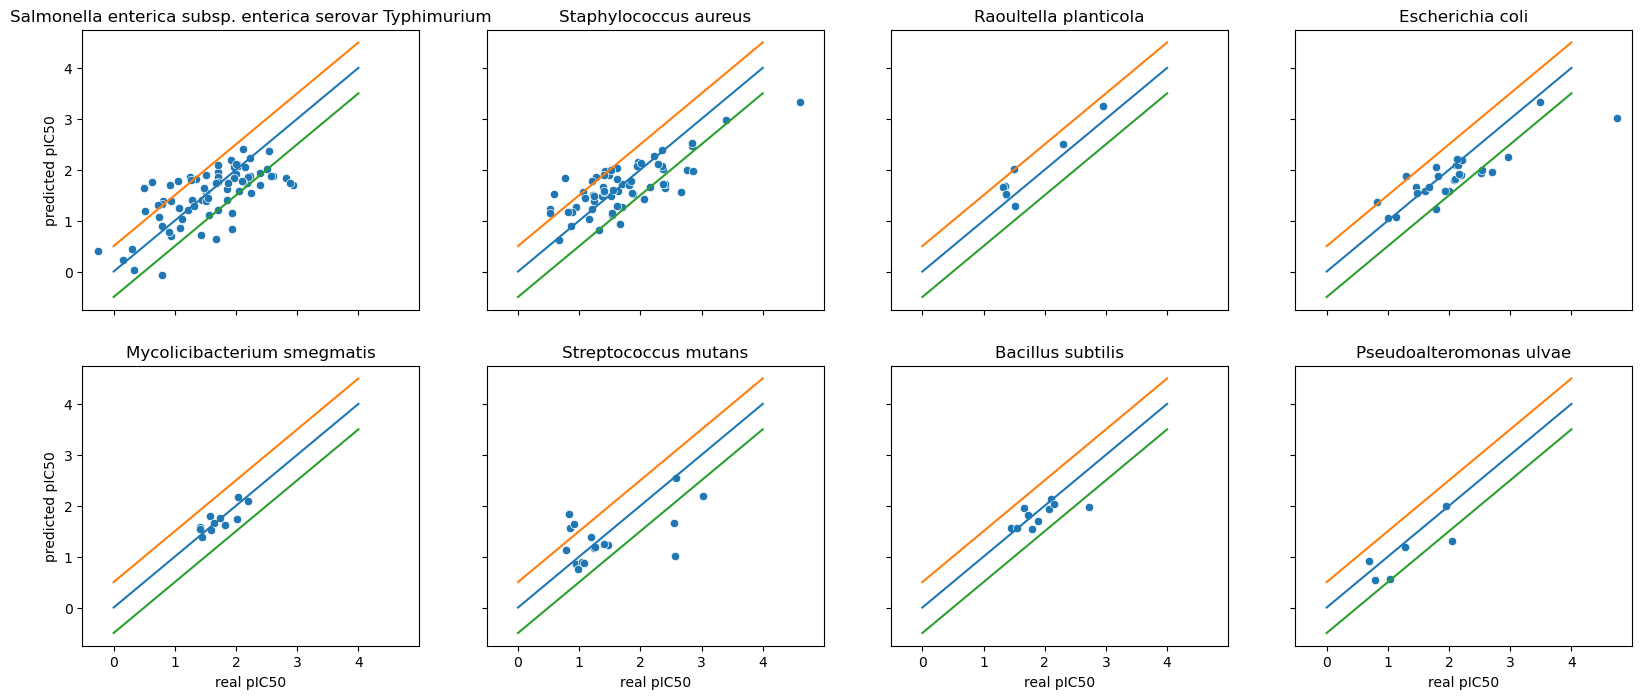

In [5]:
fig, axes = plt.subplots(2, 4, sharex="all", sharey="all", figsize = (20, 8))
for i, specie in enumerate(data.target_organism.unique()):
    ax = axes[i//4][i%4]
    sns.scatterplot(data[data.target_organism.eq(specie)], x="real pIC50", y="predicted pIC50", ax=ax)
    sns.lineplot(x = [0,4], y=[0,4], ax=ax)
    sns.lineplot(x = [0,4], y=[0.5, 4.5], ax=ax)
    sns.lineplot(x = [0,4], y=[-0.5, 3.5], ax=ax)
    ax.set_title(specie)

In [6]:
from collections import defaultdict

metrics = defaultdict(dict)

for specie in data.target_organism.unique():
    subdata = data[data.target_organism.eq(specie)]
    y = subdata["real pIC50"]
    y_pred = subdata["predicted pIC50"]
    metrics["R2"][specie] = r2_score(y, y_pred)
    metrics["MSE"][specie] =  mean_squared_error(y, y_pred)
    metrics["RMSE"][specie] =  mean_squared_error(y, y_pred)**0.5

metrics = pd.DataFrame(metrics)

metrics

,R2,MSE,RMSE
Salmonella enterica subsp. enterica serovar Typhimurium,0.426143,0.266581,0.516315
Staphylococcus aureus,0.566240,0.232807,0.482501
Raoultella planticola,0.704227,0.092249,0.303726
Escherichia coli,0.607335,0.237612,0.487454
Mycolicibacterium smegmatis,0.655973,0.023261,0.152517
Streptococcus mutans,0.265950,0.371823,0.609773
Bacillus subtilis,0.344845,0.080483,0.283694
Pseudoalteromonas ulvae,0.455895,0.152780,0.390871
